## Question 2: Data Cleaning

In [35]:
import pandas as pd
import os

In [37]:
#get working directory
directory=r"C:\\Users\\mahan\\Documents\\Sem 1\\STQD6014 DATA SCIENCE\\2. Dr Afiqah\\Project 2"
os.chdir(directory)

In [39]:
#import raw data
data=pd.read_csv('opendata_covid19_vaccination_agegroup.csv')
print(data)

       StatisticsDate  TargetDiseaseCode TargetDisease AgeGroup  \
0          2020-12-27                219      COVID-19      NaN   
1          2020-12-27                219      COVID-19      NaN   
2          2020-12-27                219      COVID-19      NaN   
3          2020-12-27                219      COVID-19      NaN   
4          2020-12-27                219      COVID-19      NaN   
...               ...                ...           ...      ...   
332419     2024-12-23                219      COVID-19      80+   
332420     2024-12-23                219      COVID-19      80+   
332421     2024-12-23                219      COVID-19      80+   
332422     2024-12-23                219      COVID-19      80+   
332423     2024-12-23                219      COVID-19      80+   

        VaccinationSeries    MeasurementType  LocationPopulation  DailyCount  \
0                       1  DosesAdministered                 NaN           0   
1                       1    FullyV

In [41]:
#Check missing data
summary_missing=data.isna().sum()
print(summary_missing)

StatisticsDate             0
TargetDiseaseCode          0
TargetDisease              0
AgeGroup               27702
VaccinationSeries          0
MeasurementType            0
LocationPopulation     27702
DailyCount                 0
TotalCount                 0
PopulationCoverage    172044
dtype: int64


In [43]:
#Handling missing data
data=data.dropna(subset=['AgeGroup','LocationPopulation'],axis=0)
data['PopulationCoverage']=data['PopulationCoverage'].fillna(0)

#Recheck missing dataa
summary2_missing=data.isna().sum()
print(summary2_missing)

StatisticsDate        0
TargetDiseaseCode     0
TargetDisease         0
AgeGroup              0
VaccinationSeries     0
MeasurementType       0
LocationPopulation    0
DailyCount            0
TotalCount            0
PopulationCoverage    0
dtype: int64


In [11]:
#check duplicated rows
dupli=data.duplicated().sum()
print(dupli)

0


In [45]:
#Check unique values
for column_name in data.columns:
    print(f'Column:{column_name}')
    unique_value=data[column_name].unique()
    print(unique_value)

Column:StatisticsDate
['2020-12-27' '2020-12-28' '2020-12-29' ... '2024-12-21' '2024-12-22'
 '2024-12-23']
Column:TargetDiseaseCode
[219]
Column:TargetDisease
['COVID-19']
Column:AgeGroup
['0-4' '12-15' '16-17' '18-29' '30-39' '40-49' '5-11' '50-59' '60-69'
 '70-79' '80+']
Column:VaccinationSeries
[ 1  2  3  4  5  6  7  8 10]
Column:MeasurementType
['DosesAdministered' 'FullyVaccinated' 'Vaccinated']
Column:LocationPopulation
[ 71235.  56876.  24982. 169308. 196352. 182795. 103951. 171453. 163237.
 111342.  77358.  70321.  59238.  25917. 162764. 198484. 183010. 102751.
 171103. 164770. 112691.  79019.  69534.  60788.  27186. 159545. 199035.
 183636. 101830. 171562. 165599. 112898.  80183.  69643.  64893.  29335.
 162786. 205829. 189109. 105240. 174783. 168239. 115840.  80187.]
Column:DailyCount
[  0  11  40 ... 774 582 750]
Column:TotalCount
[    0    11    40 ... 12114 12159  5397]
Column:PopulationCoverage
[0.000e+00 1.000e-02 2.000e-02 ... 1.411e+01 6.710e+00 1.516e+01]


In [47]:
#Check data types 
data.dtypes

StatisticsDate         object
TargetDiseaseCode       int64
TargetDisease          object
AgeGroup               object
VaccinationSeries       int64
MeasurementType        object
LocationPopulation    float64
DailyCount              int64
TotalCount              int64
PopulationCoverage    float64
dtype: object

In [49]:
#Convert to datetime data type
data['StatisticsDate']=pd.to_datetime(data['StatisticsDate'],errors='coerce')
data.head()

,StatisticsDate,TargetDiseaseCode,TargetDisease,AgeGroup,VaccinationSeries,MeasurementType,LocationPopulation,DailyCount,TotalCount,PopulationCoverage
19,2020-12-27,219,COVID-19,0-4,1,DosesAdministered,71235.0,0,0,0.0
20,2020-12-27,219,COVID-19,0-4,1,FullyVaccinated,71235.0,0,0,0.0
21,2020-12-27,219,COVID-19,0-4,1,Vaccinated,71235.0,0,0,0.0
22,2020-12-27,219,COVID-19,0-4,2,DosesAdministered,71235.0,0,0,0.0
23,2020-12-27,219,COVID-19,0-4,2,FullyVaccinated,71235.0,0,0,0.0


In [51]:
#Recheck data types
data.dtypes

StatisticsDate        datetime64[ns]
TargetDiseaseCode              int64
TargetDisease                 object
AgeGroup                      object
VaccinationSeries              int64
MeasurementType               object
LocationPopulation           float64
DailyCount                     int64
TotalCount                     int64
PopulationCoverage           float64
dtype: object

In [53]:
#Standardize categorical values
data['MeasurementType']=data['MeasurementType'].str.replace(r'([a-z])([A-Z])',r'\1 \2',regex=True)
print(data['MeasurementType'].unique())

['Doses Administered' 'Fully Vaccinated' 'Vaccinated']


In [55]:
#Standardize column names
data.rename(columns={
    'StatisticsDate':'Statistics Date',
    'TargetDiseaseCode':'Target Disease Code',
    'TargetDisease':'Target Disease',
    'AgeGroup':'Age Group',
    'VaccinationSeries':'Vaccination Series',
    'MeasurementType':'Measurement Type',
    'LocationPopulation':'Location Population',
    'DailyCount':'Daily Count',
    'TotalCount':'Total Count',
    'PopulationCoverage':'Population Coverage', 
},inplace=True)

print(data.columns)

Index(['Statistics Date', 'Target Disease Code', 'Target Disease', 'Age Group',
       'Vaccination Series', 'Measurement Type', 'Location Population',
       'Daily Count', 'Total Count', 'Population Coverage'],
      dtype='object')


## Question 3: Analysis & Insights

In [57]:
#Extract descriptive statistics
descriptive_stats=data.describe(include='all')
print(descriptive_stats)

            Statistics Date  Target Disease Code Target Disease Age Group  \
count                304722             304722.0         304722    304722   
unique                  NaN                  NaN              1        11   
top                     NaN                  NaN       COVID-19       0-4   
freq                    NaN                  NaN         304722     27702   
mean    2022-12-25 12:00:00                219.0            NaN       NaN   
min     2020-12-27 00:00:00                219.0            NaN       NaN   
25%     2021-12-26 00:00:00                219.0            NaN       NaN   
50%     2022-12-25 12:00:00                219.0            NaN       NaN   
75%     2023-12-25 00:00:00                219.0            NaN       NaN   
max     2024-12-23 00:00:00                219.0            NaN       NaN   
std                     NaN                  0.0            NaN       NaN   

        Vaccination Series    Measurement Type  Location Population  \
coun

In [59]:
#Extract the mode for each column
mode_column=data.mode().iloc[0]
print(mode_column)

Statistics Date        2020-12-27 00:00:00
Target Disease Code                  219.0
Target Disease                    COVID-19
Age Group                              0-4
Vaccination Series                     1.0
Measurement Type        Doses Administered
Location Population                29335.0
Daily Count                            0.0
Total Count                            0.0
Population Coverage                    0.0
Name: 0, dtype: object


In [61]:
#Correlation analysis (for numerical variables)
numerical=data.select_dtypes(include=['number'])
correlation=numerical.corr()
print(correlation)

                     Target Disease Code  Vaccination Series  \
Target Disease Code                  NaN                 NaN   
Vaccination Series                   NaN        1.000000e+00   
Location Population                  NaN       -1.738864e-16   
Daily Count                          NaN       -1.633732e-01   
Total Count                          NaN       -5.052418e-01   
Population Coverage                  NaN       -4.313147e-01   

                     Location Population  Daily Count  Total Count  \
Target Disease Code                  NaN          NaN          NaN   
Vaccination Series         -1.738864e-16    -0.163373    -0.505242   
Location Population         1.000000e+00     0.072684     0.236456   
Daily Count                 7.268424e-02     1.000000     0.137733   
Total Count                 2.364561e-01     0.137733     1.000000   
Population Coverage         8.561317e-02     0.070122     0.546298   

                     Population Coverage  
Target Disease Co

In [63]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

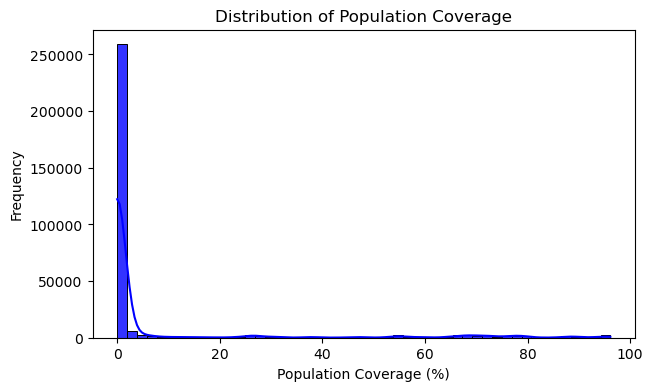

In [64]:
#Distribution of Population Coverage
plt.figure(figsize=(7,4))
sns.histplot(data['Population Coverage'], kde=True, bins=50, color='blue',alpha=0.8)
plt.title("Distribution of Population Coverage")
plt.xlabel("Population Coverage (%)")
plt.ylabel("Frequency")
plt.show()

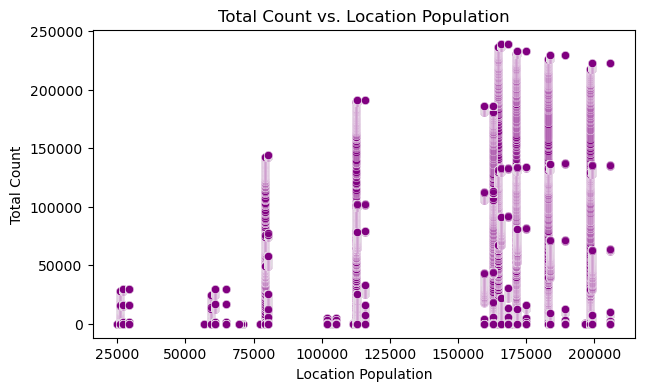

In [67]:
#Total count vs Location population  
plt.figure(figsize=(7,4))
sns.scatterplot(x='Location Population', y='Total Count', data=data, alpha=0.6, color='purple')
plt.title("Total Count vs. Location Population")
plt.xlabel("Location Population")
plt.ylabel("Total Count")
plt.show()

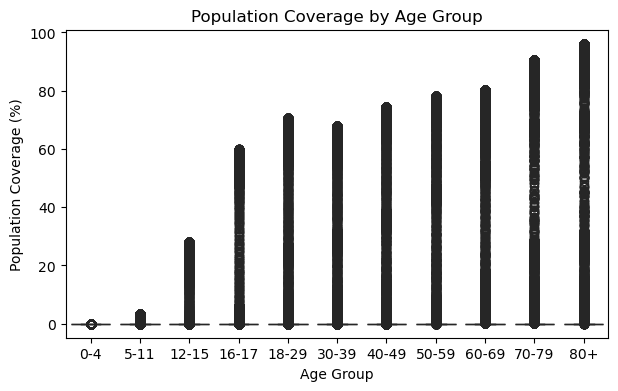

In [81]:
#Population coverage by age group
#Define the correct order for the age groups
age_order = ['0-4', '5-11', '12-15', '16-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
#Plot with the specified order
plt.figure(figsize=(7,4))
sns.boxplot(x='Age Group', y='Population Coverage', data=data, order=age_order, color='gray')
plt.title("Population Coverage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Population Coverage (%)")
plt.show()

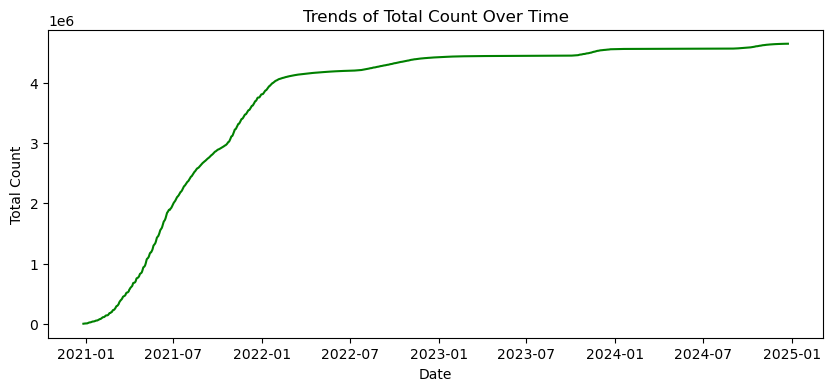

In [87]:
plt.figure(figsize=(10, 4))
data_grouped_date = data.groupby('Statistics Date')['Total Count'].sum().reset_index()
sns.lineplot(x='Statistics Date', y='Total Count', data=data_grouped_date, color='green')
plt.title("Trends of Total Count Over Time")
plt.xlabel("Date")
plt.ylabel("Total Count")
plt.show()

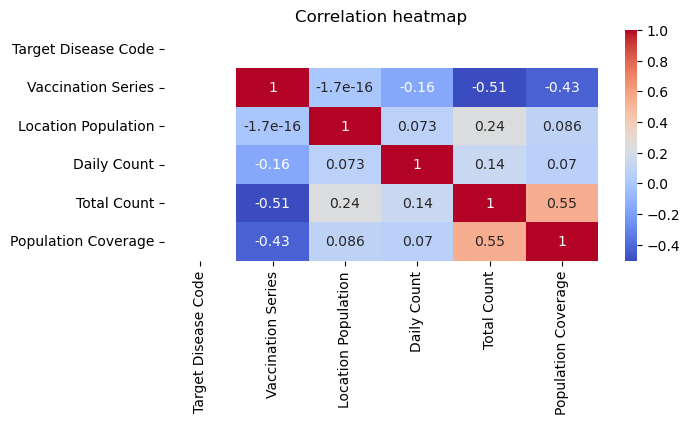

In [89]:
#Heatmap of correlation
plt.figure(figsize=(7,3))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()